<a href="https://colab.research.google.com/github/Satyam-Mittal2527/Deep_Learning_Concepts/blob/main/BackPropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# def initalize_par(layers_dims):
#   parameters = {}
#   l = len(layers_dims)
#   for i in range(l-1):
#     parameters['W'+ str(i+1)] = np.ones((layers_dims[i], layers_dims[i+1]))*0.1;
#     parameters['B'+ str(i+1)] = np.zeros((layers_dims[i+1],1))
#   return parameters

In [ ]:
# print(initalize_par([2,2,1]))

In [ ]:
# df

In [ ]:
# print(initalize_par([2,2,1]))

In [ ]:
# parameters = initalize_par([2,2,1])

In [ ]:
# parameters['W1'][1][1]

In [ ]:
# def forward(W,B,A):
#   Z = np.dot(W.T,A)+B
#   return Z

In [ ]:
# def forward_prop(X,parameters):
#   l= len(parameters)//2;
#   A=X
#   W=[]
#   b=[]
#   for i in range(l):
#     A_prev = A;
#     W = parameters['W' + str(i+1)]
#     # print(parameters['W'+str(i+1)])
#     # print(parameters['B'+str(i+1)])
#     # print(A_prev)
#     # print("--"*20)
#     B = parameters['B' + str(i+1)]
#     A = forward(W,B,A_prev)
#     # print(A)
#     # print("--"*20)

#   return A,A_prev

In [ ]:
# X = df[['cgpa','profile_score']].values[3].reshape(2,1)
# X[1][0]
# # y = df[['lpa']].values[1][0]
# # print(y)

In [ ]:
# y_hat,y=forward_prop(X,parameters)

In [ ]:
# y_hat[0][0]
# print(df[['lpa'][0]][0])

In [ ]:
# loss_function(df[['lpa'][0]][0],y_hat[0][0])

In [ ]:
# # print(parameters['W2'][0][0])
# # print(y_hat[0][0])
# # df[['cgpa','profile_score'][1]][1]
# print(df.shape[0])

In [ ]:
# parameters['W2'][0][0]

In [ ]:
# parameters = backPropagation(parameters, df['lpa'][0], y_hat[0][0],y, df)

# df[['cgpa','profile_score'][1]][0]

In [ ]:
# parameters

#REGRESSION PROBLEM

In [ ]:
import numpy as np
import pandas as pd
import time

In [ ]:
df = pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]], columns=['cgpa','profile_score','lpa'])
df

,cgpa,profile_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [ ]:
def initalize_par(layers_dims):
  parameters = {}
  l = len(layers_dims)
  for i in range(l-1):
    parameters['W'+ str(i+1)] = np.ones((layers_dims[i], layers_dims[i+1]))*0.1;
    parameters['B'+ str(i+1)] = np.zeros((layers_dims[i+1],1))
  return parameters

In [ ]:
def loss_function(y,y_hat):
  loss = (y-y_hat)**2
  return loss

In [ ]:
loss = []

In [ ]:
def forward(W,B,A):
  Z = np.dot(W.T,A)+B
  return Z

In [ ]:
def forward_prop(X,parameters):
  l= len(parameters)//2;
  A=X
  W=[]
  b=[]
  for i in range(l):
    A_prev = A;
    W = parameters['W' + str(i+1)]
    # print(parameters['W'+str(i+1)])
    # print(parameters['B'+str(i+1)])
    # print(A_prev)
    # print("--"*20)
    B = parameters['B' + str(i+1)]
    A = forward(W,B,A_prev)
    # print(A)
    # print("--"*20)

  return A,A_prev

In [ ]:
def backPropagation(parameters, y,y_hat,A,X):
  parameters['W2'][0][0] = parameters['W2'][0][0] + (0.001*2*(y-y_hat))*A[0][0]
  parameters['W2'][1][0] = parameters['W2'][1][0] + (0.001*2*(y-y_hat))*A[1][0]
  parameters['B2'][0][0] = parameters['B2'][0][0] + (0.001*2*(y-y_hat))
  #Have to Update the formula
  parameters['W1'][0][0] = parameters['W1'][0][0] + (0.001*2*(y-y_hat))*X[0][0]
  parameters['W1'][0][1] = parameters['W1'][0][1] + (0.001*2*(y-y_hat))*X[0][0]
  parameters['B1'][0][0] = parameters['B1'][0][0] + (0.001*2*(y-y_hat))

  parameters['W1'][1][0] = parameters['W1'][1][0] + (0.001*2*(y-y_hat))*X[1][0]
  parameters['W1'][1][1] = parameters['W1'][1][1] + (0.001*2*(y-y_hat))*X[1][0]
  parameters['B1'][1][0] = parameters['B1'][1][0] + (0.001*2*(y-y_hat))

  return parameters

In [ ]:
parameters = initalize_par([2,2,1])
start = time.time()
for i in range(10):
  loss_perIter = []
  for j in range(df.shape[0]):
    X = df[['cgpa','profile_score']].values[j].reshape(2,1)
    y_true = df[['lpa']].values[j][0]
    y_hat, A = forward_prop(X,parameters)
    y_pred = y_hat[0][0]
    loss_perIter.append(loss_function(y_true,y_hat[0][0]))
    parameters = backPropagation(parameters,y_true,y_pred,A, X)
  avg_loss = sum(loss_perIter)/len(loss_perIter)
  print(f'Epoch: {i} Loss: {avg_loss}')
  loss.append(avg_loss)
print(time.time()-start)

Epoch: 0 Loss: 20.965687533532922
Epoch: 1 Loss: 2.95905855867364
Epoch: 2 Loss: 0.9583486898911687
Epoch: 3 Loss: 1.1326541674510364
Epoch: 4 Loss: 1.1149740012290692
Epoch: 5 Loss: 1.0776174890839683
Epoch: 6 Loss: 1.040060112458893
Epoch: 7 Loss: 1.0037406372724174
Epoch: 8 Loss: 0.9687082129260833
Epoch: 9 Loss: 0.9349129477261248
0.03913116455078125


In [ ]:
parameters

{'W1': array([[0.34474086, 0.34474086],
        [0.6697679 , 0.6697679 ]]),
 'B1': array([[0.04916477],
        [0.04916477]]),
 'W2': array([[0.33818628],
        [0.33818628]]),
 'B2': array([[0.04916477]])}

In [ ]:
import matplotlib.pyplot as plt

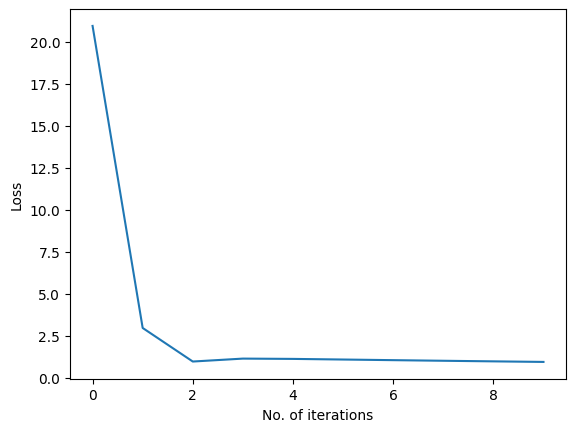

In [ ]:
plt.plot(loss)
plt.xlabel('No. of iterations')
plt.ylabel('Loss')
plt.show()

#CLASSIFICATION PROBLEM

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.DataFrame([[8,8,1],[7,9,1],[6,10,0],[5,12,0]], columns =('cgpa','profile_score','placed'))

In [ ]:
df

,cgpa,profile_score,placed
0,8,8,1
1,7,9,1
2,6,10,0
3,5,12,0


In [ ]:
def initialize_params(struc):
  params = {}
  for i in range(len(struc)-1):
    params['W'+ str(i+1)] = np.ones((struc[i],struc[i+1]))*0.1
    params['b'+ str(i+1)] = np.zeros((struc[i+1],1))
  return params

In [ ]:
print(initialize_params([2,2,1]))
parameter = initialize_params([2,2,1])

{'W1': array([[0.1, 0.1],
       [0.1, 0.1]]), 'b1': array([[0.],
       [0.]]), 'W2': array([[0.1],
       [0.1]]), 'b2': array([[0.]])}


In [ ]:
def sigmoid(z):
  output = 1/ (1+np.exp(-z))
  return output

In [ ]:
def forward(W,B,x):
  z = np.dot(W.T,x)+B
  o = sigmoid(z)
  return o

In [ ]:
def forward_pass(para,x):
  A = x
  W = []
  B = []
  for i in range(len(para)//2):
    A_prev = A
    W = para['W'+ str(i+1)]
    B = para['b' + str(i+1)]
    # print(W)
    # print(B)
    # print(A_prev)
    # print('---'*20)
    A = forward(W,B,A_prev)
    # print(A)
    # print('---'*20)
  return A,A_prev

In [ ]:
def loss_func(y_pred, y_true):
  loss = -y_true*np.log(y_pred) + -(1-y_true)*np.log(1-y_pred)
  return loss

In [ ]:
X = df[['cgpa', 'profile_score']].values[3].reshape(2,1)
y_true = df['placed'].values[1]
print(X)
print(y_true)
A, A_prev = forward_pass(parameter,X)
y_pred = A[0][0]
print(y_pred)
print(y_true)

[[ 5]
 [12]]
1
0.5430149002058879
1


In [ ]:
print(loss_func(y_pred,y_true))

0.6106185188981889


In [ ]:
print(y_pred)

0.5430149002058879


In [ ]:
def update_params(parameter,A_prev,X,y_pred, y_true):
  parameter['W2'][0][0] = parameter['W2'][0][0] + (0.001*(y_true-y_pred))*A_prev[0][0]
  parameter['W2'][1][0] = parameter['W2'][1][0] + (0.001*(y_true-y_pred))*A_prev[1][0]
  parameter['b2'][0][0] = parameter['b2'][0][0] + (0.001*(y_true-y_pred))

  parameter['W1'][0][0] = parameter['W1'][0][0] + (0.001*(y_true-y_pred))*parameter['W2'][0][0]*(A_prev[0][0]*(1-A_prev[0][0]))*X[0][0]
  parameter['W1'][0][1] = parameter['W1'][0][1] + (0.001*(y_true-y_pred))*parameter['W2'][0][0]*(A_prev[0][0]*(1-A_prev[0][0]))*X[1][0]
  parameter['b1'][0][0] = parameter['b1'][0][0] + (0.001*(y_true-y_pred))*parameter['W2'][0][0]*(A_prev[0][0]*(1-A_prev[0][0]))

  parameter['W1'][1][0] = parameter['W1'][1][0] + (0.001*(y_true-y_pred))*parameter['W2'][1][0]*(A_prev[1][0]*(1-A_prev[1][0]))*X[0][0]
  parameter['W1'][1][1] = parameter['W1'][1][1] + (0.001*(y_true-y_pred))*parameter['W2'][1][0]*(A_prev[1][0]*(1-A_prev[1][0]))*X[1][0]
  parameter['b1'][1][0] = parameter['b1'][1][0] + (0.001*(y_true-y_pred))*parameter['W2'][1][0]*(A_prev[1][0]*(1-A_prev[1][0]))

  return parameter

In [ ]:
update_params(parameter, A_prev, X, y_pred,y_true)

{'W1': array([[0.10022651, 0.10039281],
        [0.10022646, 0.1003927 ]]),
 'b1': array([[3.75683667e-05],
        [3.75591935e-05]]),
 'W2': array([[0.10230349],
        [0.10230363]]),
 'b2': array([[0.00274561]])}

In [ ]:
parameters = initialize_params([2,2,1])
avg_loss = []
loss=[]
for i in range(100):
  for j in range(df.shape[0]):
    X = df[['cgpa','profile_score']].values[j].reshape(2,1)
    y_true = df['placed'].values[j]
    A,A_prev = forward_pass(parameters,X)
    y_pred = A[0][0]
    loss.append(loss_func(y_pred,y_true))
    parameters = update_params(parameters,A_prev,X,y_pred,y_true)
  avgLoss = sum(loss)/len(loss)
  avg_loss.append(avgLoss)
  print(f'Epochs:{i},Loss:{avgLoss}')
  loss.clear()

Epochs:0,Loss:0.6972699425915958
Epochs:1,Loss:0.6972519155780772
Epochs:2,Loss:0.6972339773177152
Epochs:3,Loss:0.6972161273644475
Epochs:4,Loss:0.6971983652745164
Epochs:5,Loss:0.6971806906064558
Epochs:6,Loss:0.6971631029210816
Epochs:7,Loss:0.6971456017814758
Epochs:8,Loss:0.6971281867529775
Epochs:9,Loss:0.6971108574031689
Epochs:10,Loss:0.6970936133018646
Epochs:11,Loss:0.6970764540210985
Epochs:12,Loss:0.6970593791351127
Epochs:13,Loss:0.6970423882203459
Epochs:14,Loss:0.6970254808554208
Epochs:15,Loss:0.6970086566211332
Epochs:16,Loss:0.6969919151004398
Epochs:17,Loss:0.6969752558784476
Epochs:18,Loss:0.6969586785424009
Epochs:19,Loss:0.6969421826816716
Epochs:20,Loss:0.6969257678877465
Epochs:21,Loss:0.6969094337542172
Epochs:22,Loss:0.6968931798767671
Epochs:23,Loss:0.6968770058531628
Epochs:24,Loss:0.6968609112832405
Epochs:25,Loss:0.6968448957688963
Epochs:26,Loss:0.6968289589140753
Epochs:27,Loss:0.6968131003247597
Epochs:28,Loss:0.6967973196089594
Epochs:29,Loss:0.6967816

Text(0, 0.5, 'Loss')

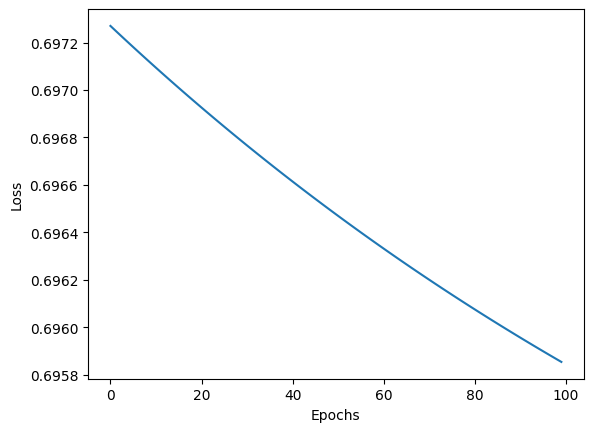

In [ ]:
import matplotlib.pyplot as plt
plt.plot(avg_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')